# Scenario 1 DL4DS (Forecast Correction)
This notebook reuses the Scenario 1 data flow (IFS low-res forecast + ERA5 high-res truth) and trains DL4DS per variable.

In [ ]:
import os

os.chdir('/home/jovyan/work')  # Move to climate-research-workbench root
print(f'CWD: {os.getcwd()}')

CWD: /home/jovyan/work


In [2]:
import os
os.environ['SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL'] = 'True'

# Install DL4DS stack (run once per fresh environment)
!pip install dl4ds climetlab
!pip uninstall keras -y
!pip install "tensorflow[and-cuda]==2.15.*"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 14.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 MB 54.6 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 34.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 35.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.7/574.7 kB 22.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 33.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 38.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 40.3 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.7/661.7 kB 28.4 MB/s  0:00:00


In [3]:
# ==========================================
# Run folder + logger
# ==========================================
import json as _json
import datetime as _dt

_run_start = _dt.datetime.now()
_run_id = _run_start.strftime('%Y%m%d_%H%M%S')
RUN_DIR = os.path.join('runs', f'{_run_id}_sc1_dl4ds')
os.makedirs(RUN_DIR, exist_ok=True)
_LOG_PATH = os.path.join(RUN_DIR, 'runtime.log')

VAR_LABELS = ['U10 (m/s)', 'V10 (m/s)', 'T2m (K)', 'TP 24hr (mm)']

def _log(msg: str):
    ts = _dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{ts}] {msg}'
    print(line)
    with open(_LOG_PATH, 'a') as f:
        f.write(line + '\n')

_log(f'=== Run started (id={_run_id}) ===')
_log(f'Run dir: {RUN_DIR}')

[2026-04-14 06:13:41] === Run started (id=20260414_061341) ===
[2026-04-14 06:13:41] Run dir: runs/20260414_061341_sc1_dl4ds


In [4]:
# ==========================================
# Imports + config
# ==========================================
import numpy as np
import pandas as pd
import xarray as xr
import tensorflow as tf
import dl4ds as dds

scale = 6
lead_days = 1
lead_td = np.timedelta64(lead_days, 'D')
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

train_start_date = '2018-01-01'
train_end_date = '2021-12-31'
val_start_date = '2022-01-01'
val_end_date = '2022-06-30'
test_start_date = '2022-07-01'
test_end_date = '2022-12-31'

_config = {
    'scenario': 'scenario1-dl4ds-forecast-correction',
    'run_id': _run_id,
    'run_dir': RUN_DIR,
    'scale': scale,
    'lead_days': int(lead_days),
    'seed': int(seed),
    'train_start_date': train_start_date,
    'train_end_date': train_end_date,
    'val_start_date': val_start_date,
    'val_end_date': val_end_date,
    'test_start_date': test_start_date,
    'test_end_date': test_end_date,
    'started_at': _run_start.isoformat()
}
with open(os.path.join(RUN_DIR, 'config.json'), 'w') as f:
    _json.dump(_config, f, indent=2)
_log('Config saved -> config.json')

2026-04-14 06:13:43.769949: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 06:13:43.837573: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-14 06:13:43.837623: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-14 06:13:43.839134: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-14 06:13:43.850365: I tensorflow/core/platform/cpu_feature_guar

[2026-04-14 06:13:53] Config saved -> config.json


In [5]:
# ==========================================
# Load Scenario 1 datasets
# ==========================================
ds_forecast = xr.open_dataset('data/ifs_lowres_indonesia_2018-2022.zarr')
ds_truth = xr.open_dataset('data/era5_indonesia_2018-2022.zarr')

# Lead selection
ds_forecast = ds_forecast.sel(prediction_timedelta=lead_td)

# Sort latitude for stable slicing
ds_truth = ds_truth.sortby('latitude')
ds_forecast = ds_forecast.sortby('latitude')

print('Forecast dims:', ds_forecast.dims)
print('Truth dims   :', ds_truth.dims)

Forecast dims: FrozenMappingWarningOnValuesAccess({'time': 3652, 'longitude': 42, 'latitude': 33})
Truth dims   : FrozenMappingWarningOnValuesAccess({'time': 7304, 'latitude': 181, 'longitude': 201})


In [6]:
# ==========================================
# Spatial crop using SC1 logic (target 24x32 -> 144x192)
# ==========================================
tr_lons = ds_truth.longitude.values
tr_lats = ds_truth.latitude.values
fc_lons = ds_forecast.longitude.values
fc_lats = ds_forecast.latitude.values

valid_lons = fc_lons[(fc_lons >= tr_lons.min()) & (fc_lons <= tr_lons.max())]
valid_lats = fc_lats[(fc_lats >= tr_lats.min()) & (fc_lats <= tr_lats.max())]

lon_start = valid_lons[0]
lat_start = valid_lats[0]

lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))

avail_lon = len(tr_lons) - lon_start_idx
avail_lat = len(tr_lats) - lat_start_idx
max_fc_lon = min(avail_lon // scale, 32)
max_fc_lat = min(avail_lat // scale, 24)

fc_lon_start_idx = np.argmin(np.abs(fc_lons - lon_start))
fc_lat_start_idx = np.argmin(np.abs(fc_lats - lat_start))

ds_fc = ds_forecast.isel(
    longitude=slice(fc_lon_start_idx, fc_lon_start_idx + max_fc_lon),
    latitude=slice(fc_lat_start_idx, fc_lat_start_idx + max_fc_lat)
)

LOW_LON = len(ds_fc.longitude)
LOW_LAT = len(ds_fc.latitude)

ds_tr = ds_truth.isel(
    longitude=slice(lon_start_idx, lon_start_idx + LOW_LON * scale),
    latitude=slice(lat_start_idx, lat_start_idx + LOW_LAT * scale)
)

print(f'Low-res grid  : {LOW_LAT} x {LOW_LON}')
print(f'High-res grid : {len(ds_tr.latitude)} x {len(ds_tr.longitude)}')

Low-res grid  : 24 x 32
High-res grid : 144 x 192


In [7]:
# ==========================================
# Temporal alignment
# ==========================================
valid_time = ds_fc.time + lead_td
common_times = np.intersect1d(valid_time.values, ds_tr.time.values)

ds_fc = ds_fc.assign_coords(valid_time=valid_time)
ds_fc = ds_fc.sel(valid_time=common_times)
ds_fc = ds_fc.assign_coords(time=ds_fc.valid_time).drop_vars('valid_time')
ds_tr_aligned = ds_tr.sel(time=common_times)

print('Common timesteps:', len(common_times))
print('Forecast and truth time aligned:', np.array_equal(ds_fc.time.values, ds_tr_aligned.time.values))

Common timesteps: 3650
Forecast and truth time aligned: True


In [12]:
# ==========================================
# DL4DS training per variable (tutorial-style)
# ==========================================
VARS = [
    '10m_u_component_of_wind',
    '10m_v_component_of_wind',
    '2m_temperature',
    'total_precipitation_24hr',
]

VAR_LABEL_MAP = {
    '10m_u_component_of_wind': VAR_LABELS[0],
    '10m_v_component_of_wind': VAR_LABELS[1],
    '2m_temperature': VAR_LABELS[2],
    'total_precipitation_24hr': VAR_LABELS[3],
}

var_names = [v for v in VARS if v in ds_fc.data_vars and v in ds_tr_aligned.data_vars]
if not var_names:
    raise ValueError('No overlapping variables found between ds_fc and ds_tr_aligned.')

times = ds_fc.time.values
train_mask = (times >= np.datetime64(train_start_date)) & (times <= np.datetime64(train_end_date))
val_mask = (times >= np.datetime64(val_start_date)) & (times <= np.datetime64(val_end_date))
test_mask = (times >= np.datetime64(test_start_date)) & (times <= np.datetime64(test_end_date))

if not (train_mask.any() and val_mask.any() and test_mask.any()):
    raise ValueError('Invalid split: one of train/val/test is empty.')

train_idx = np.where(train_mask)[0]
val_idx = np.where(val_mask)[0]
test_idx = np.where(test_mask)[0]

ARCH_PARAMS = dict(
    n_filters=8,
    n_blocks=8,
    normalization=None,
    dropout_rate=0.0,
    dropout_variant='spatial',
    attention=False,
    activation='relu',
    localcon_layer=False,
)

trainers = {}
data = {}
norm_stats = {}
eval_cache = {}

def fill_nan_xr(da, var_name, tag):
    arr = da.values.astype(np.float32, copy=True)
    mask = np.isnan(arr)
    if mask.any():
        fill_val = float(np.nanmean(arr))
        arr[mask] = fill_val
        print(f"  {tag} {var_name}: filled {int(mask.sum())} NaNs with mean={fill_val:.4f}")
    return xr.DataArray(arr, coords=da.coords, dims=da.dims, name=da.name)

def save_fig(fig, fname, dpi=150):
    fpath = os.path.join(RUN_DIR, fname)
    fig.savefig(fpath, dpi=dpi, bbox_inches='tight')
    _log(f'Figure saved -> {fpath}')

def _extract_history(trainer):
    hist = {'train_loss': [], 'val_loss': []}

    try:
        h = getattr(trainer, 'history', None)
        if isinstance(h, dict):
            tr = h.get('loss', h.get('train_loss', []))
            va = h.get('val_loss', [])
            if len(tr) and len(va):
                hist['train_loss'] = list(tr)
                hist['val_loss'] = list(va)
                return hist
    except Exception:
        pass

    try:
        h_obj = getattr(getattr(trainer, 'model', None), 'history', None)
        if hasattr(h_obj, 'history') and isinstance(h_obj.history, dict):
            tr = h_obj.history.get('loss', [])
            va = h_obj.history.get('val_loss', [])
            if len(tr) and len(va):
                hist['train_loss'] = list(tr)
                hist['val_loss'] = list(va)
                return hist
    except Exception:
        pass

    return hist

for i, var in enumerate(var_names, start=1):
    print('\n' + '=' * 64)
    print(f'Training DL4DS variable {i}/{len(var_names)}: {var}')
    print('=' * 64)

    # Scenario-1 pairing: low-res forecast as explicit LR input, ERA5 HR as target.
    target_var = fill_nan_xr(
        ds_tr_aligned[var].transpose('time', 'latitude', 'longitude'),
        var,
        'Y',
    )
    input_var = fill_nan_xr(
        ds_fc[var].transpose('time', 'latitude', 'longitude'),
        var,
        'X',
    )

    # Scenario-1 normalization: use separate scalers for target(Y) and input(X).
    y_scaler = dds.StandardScaler(axis=None)
    y_scaler.fit(target_var.isel(time=train_idx))

    x_scaler = dds.StandardScaler(axis=None)
    x_scaler.fit(input_var.isel(time=train_idx))

    target_norm = y_scaler.transform(target_var)
    input_norm = x_scaler.transform(input_var)

    target_norm = target_norm.expand_dims(dim='channel', axis=-1)
    input_norm = input_norm.expand_dims(dim='channel', axis=-1)
    target_orig = target_var.expand_dims(dim='channel', axis=-1)

    train_data = target_orig.isel(time=train_idx).values
    mean_val = float(np.nanmean(train_data))
    std_val = float(np.nanstd(train_data))
    if std_val < 1e-8:
        std_val = 1.0

    data_var = {
        'train_target': target_norm.isel(time=train_idx),
        'val_target': target_norm.isel(time=val_idx),
        'test_target': target_norm.isel(time=test_idx),
        'train_input': input_norm.isel(time=train_idx),
        'val_input': input_norm.isel(time=val_idx),
        'test_input': input_norm.isel(time=test_idx),
        'test_target_orig': target_orig.isel(time=test_idx),
    }

    trainer = dds.SupervisedTrainer(
        backbone='resnet',
        upsampling='spc',
        data_train=data_var['train_target'],
        data_val=data_var['val_target'],
        data_test=data_var['test_target'],
        data_train_lr=data_var['train_input'],
        data_val_lr=data_var['val_input'],
        data_test_lr=data_var['test_input'],
        scale=scale,
        time_window=None,
        static_vars=None,
        predictors_train=None,
        predictors_val=None,
        predictors_test=None,
        interpolation=None,
        patch_size=None,
        batch_size=60,
        loss='mae',
        epochs=100,
        steps_per_epoch=None,
        validation_steps=None,
        test_steps=None,
        learning_rate=(1e-3, 1e-4),
        lr_decay_after=1e4,
        early_stopping=False,
        patience=6,
        min_delta=0,
        save=False,
        save_path=None,
        show_plot=True,
        verbose=True,
        device='GPU',
        **ARCH_PARAMS,
    )

    trainer.run()

    trainers[var] = trainer
    data[var] = data_var
    norm_stats[var] = {'x_scaler': x_scaler, 'y_scaler': y_scaler, 'mean': mean_val, 'std': std_val}

    # ── Save chart config (training curves) ──────────────────────────────
    history = _extract_history(trainer)
    if history['train_loss'] and history['val_loss']:
        _chart1_cfg = {
            'chart'         : 'training_curves',
            'variable'      : var,
            'label'         : VAR_LABEL_MAP.get(var, var),
            'figsize'       : [14, 5],
            'loss_alpha'    : 0.8,
            'loss_beta'     : 0.2,
            'best_epoch'    : int(np.argmin(history['val_loss']) + 1),
            'best_val_loss' : float(min(history['val_loss'])),
        }
        _cfg_name = f"chart_training_curves_config_{var}.json"
        _json.dump(_chart1_cfg, open(os.path.join(RUN_DIR, _cfg_name), 'w'), indent=2)
        _log(f'Chart config saved -> {_cfg_name}')

        # Backward-compatible generic name (last variable wins)
        _json.dump(_chart1_cfg, open(os.path.join(RUN_DIR, 'chart_training_curves_config.json'), 'w'), indent=2)
        _log('Chart config saved -> chart_training_curves_config.json')

        import matplotlib.pyplot as plt

        fig, (ax1) = plt.subplots(1, 1, figsize=(7, 5))

        epochs_range = range(1, len(history['train_loss']) + 1)

        ax1.plot(epochs_range, history['train_loss'], label='Training Loss', linewidth=2)
        ax1.plot(epochs_range, history['val_loss'],   label='Validation Loss', linewidth=2)

        best_epoch = np.argmin(history['val_loss']) + 1
        best_loss  = min(history['val_loss'])
        ax1.axvline(best_epoch, color='gray', linestyle='--', alpha=0.7)
        ax1.scatter([best_epoch], [best_loss], color='tomato', zorder=5, s=80)
        ax1.annotate(
            f"best @ ep{best_epoch}\n{best_loss:.4f}",
            xy=(best_epoch, best_loss),
            xytext=(best_epoch + 2, best_loss + 0.002),
            fontsize=9, color='tomato',
        )

        ax1.set_xlabel('Epoch', fontsize=12)
        ax1.set_ylabel('Loss', fontsize=12)
        ax1.set_title(f"Combined Loss over Epochs — {VAR_LABEL_MAP.get(var, var)}", fontsize=12, fontweight='bold')
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)

        plt.suptitle('DL4DS Training Summary', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        save_fig(fig, f"dl4ds_training_curves_{var}.png", dpi=150)
        plt.show()

        print(f"\nFinal Training Loss ({var}): {history['train_loss'][-1]:.6f}")
        print(f"Final Validation Loss ({var}): {history['val_loss'][-1]:.6f}")
    else:
        _log(f'History not found for {var}; skipped training-curve chart.')

    # Inference path: prefer DL4DS Predictor; fallback to direct model.predict.
    pred_arr = None
    y_true_arr = data_var['test_target_orig'].values[:, :, :, 0].astype(np.float32)
    x_raw_arr = input_var.isel(time=test_idx).values.astype(np.float32)

    try:
        pred = dds.Predictor(
            trainer,
            data_var['test_input'],
            scale=scale,
            array_in_hr=False,
            static_vars=None,
            predictors=None,
            time_window=None,
            interpolation='inter_area',
            batch_size=8,
            scaler=y_scaler,
            save_path=None,
            save_fname=None,
            return_lr=True,
            device='CPU',
        )
        pred_out = pred.run()
        if isinstance(pred_out, (tuple, list)):
            unscaled_y_pred = pred_out[0]
        else:
            unscaled_y_pred = pred_out

        pred_arr = np.asarray(unscaled_y_pred)
        if pred_arr.ndim == 4 and pred_arr.shape[-1] == 1:
            pred_arr = pred_arr[:, :, :, 0]
        elif pred_arr.ndim == 4 and pred_arr.shape[1] == 1:
            pred_arr = pred_arr[:, 0, :, :]
        elif pred_arr.ndim != 3:
            raise ValueError(f'Unexpected Predictor output shape: {pred_arr.shape}')

        if pred_arr.shape != y_true_arr.shape:
            if pred_arr.shape == y_true_arr.shape[::-1]:
                pred_arr = np.transpose(pred_arr, (0, 2, 1))
            else:
                raise ValueError(f'Predictor output mismatch: pred {pred_arr.shape} vs true {y_true_arr.shape}')

        _log(f'Predictor inference used for {var}.')
    except Exception as e:
        _log(f'Predictor inference unavailable for {var} ({e}); falling back to model.predict loop.')
        pred_time = []
        for j in range(len(data_var['test_input'].time)):
            x_norm = data_var['test_input'].isel(time=j).values
            y_pred_norm = trainer.model.predict(np.expand_dims(x_norm, axis=0), verbose=0)[0]
            y_pred = y_pred_norm[:, :, 0] * std_val + mean_val
            if y_pred.shape != y_true_arr[j].shape:
                if y_pred.shape == y_true_arr[j].shape[::-1]:
                    y_pred = y_pred.T
                else:
                    raise ValueError(f'Spatial mismatch for {var}: pred {y_pred.shape} vs true {y_true_arr[j].shape}')
            pred_time.append(y_pred.astype(np.float32))
        pred_arr = np.stack(pred_time, axis=0)

    eval_cache[var] = {
        'pred': pred_arr.astype(np.float32),
        'true': y_true_arr.astype(np.float32),
        'raw': x_raw_arr.astype(np.float32),
        'times': data_var['test_target'].time.values,
    }



Training DL4DS variable 1/4: 10m_u_component_of_wind
  X 10m_u_component_of_wind: filled 768 NaNs with mean=-1.4693
List of devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Number of devices: 1
Global batch size: 60
--------------------------------------------------------------------------------
Starting time: 2026-04-14 07:00:19
--------------------------------------------------------------------------------
Model: "resnet_spc"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                Output Shape                                 Param #        Connected to                                 
 input_6 (InputLayer)                        [(None, None, None, 1)]                      0              []                                           
                                                                                      

[2026-04-14 07:19:09] Chart config saved -> chart_spatial_eval_config.json
[2026-04-14 07:19:17] Figure saved -> runs/20260414_061341_sc1_dl4ds/dl4ds_eval_2022-08-01.png


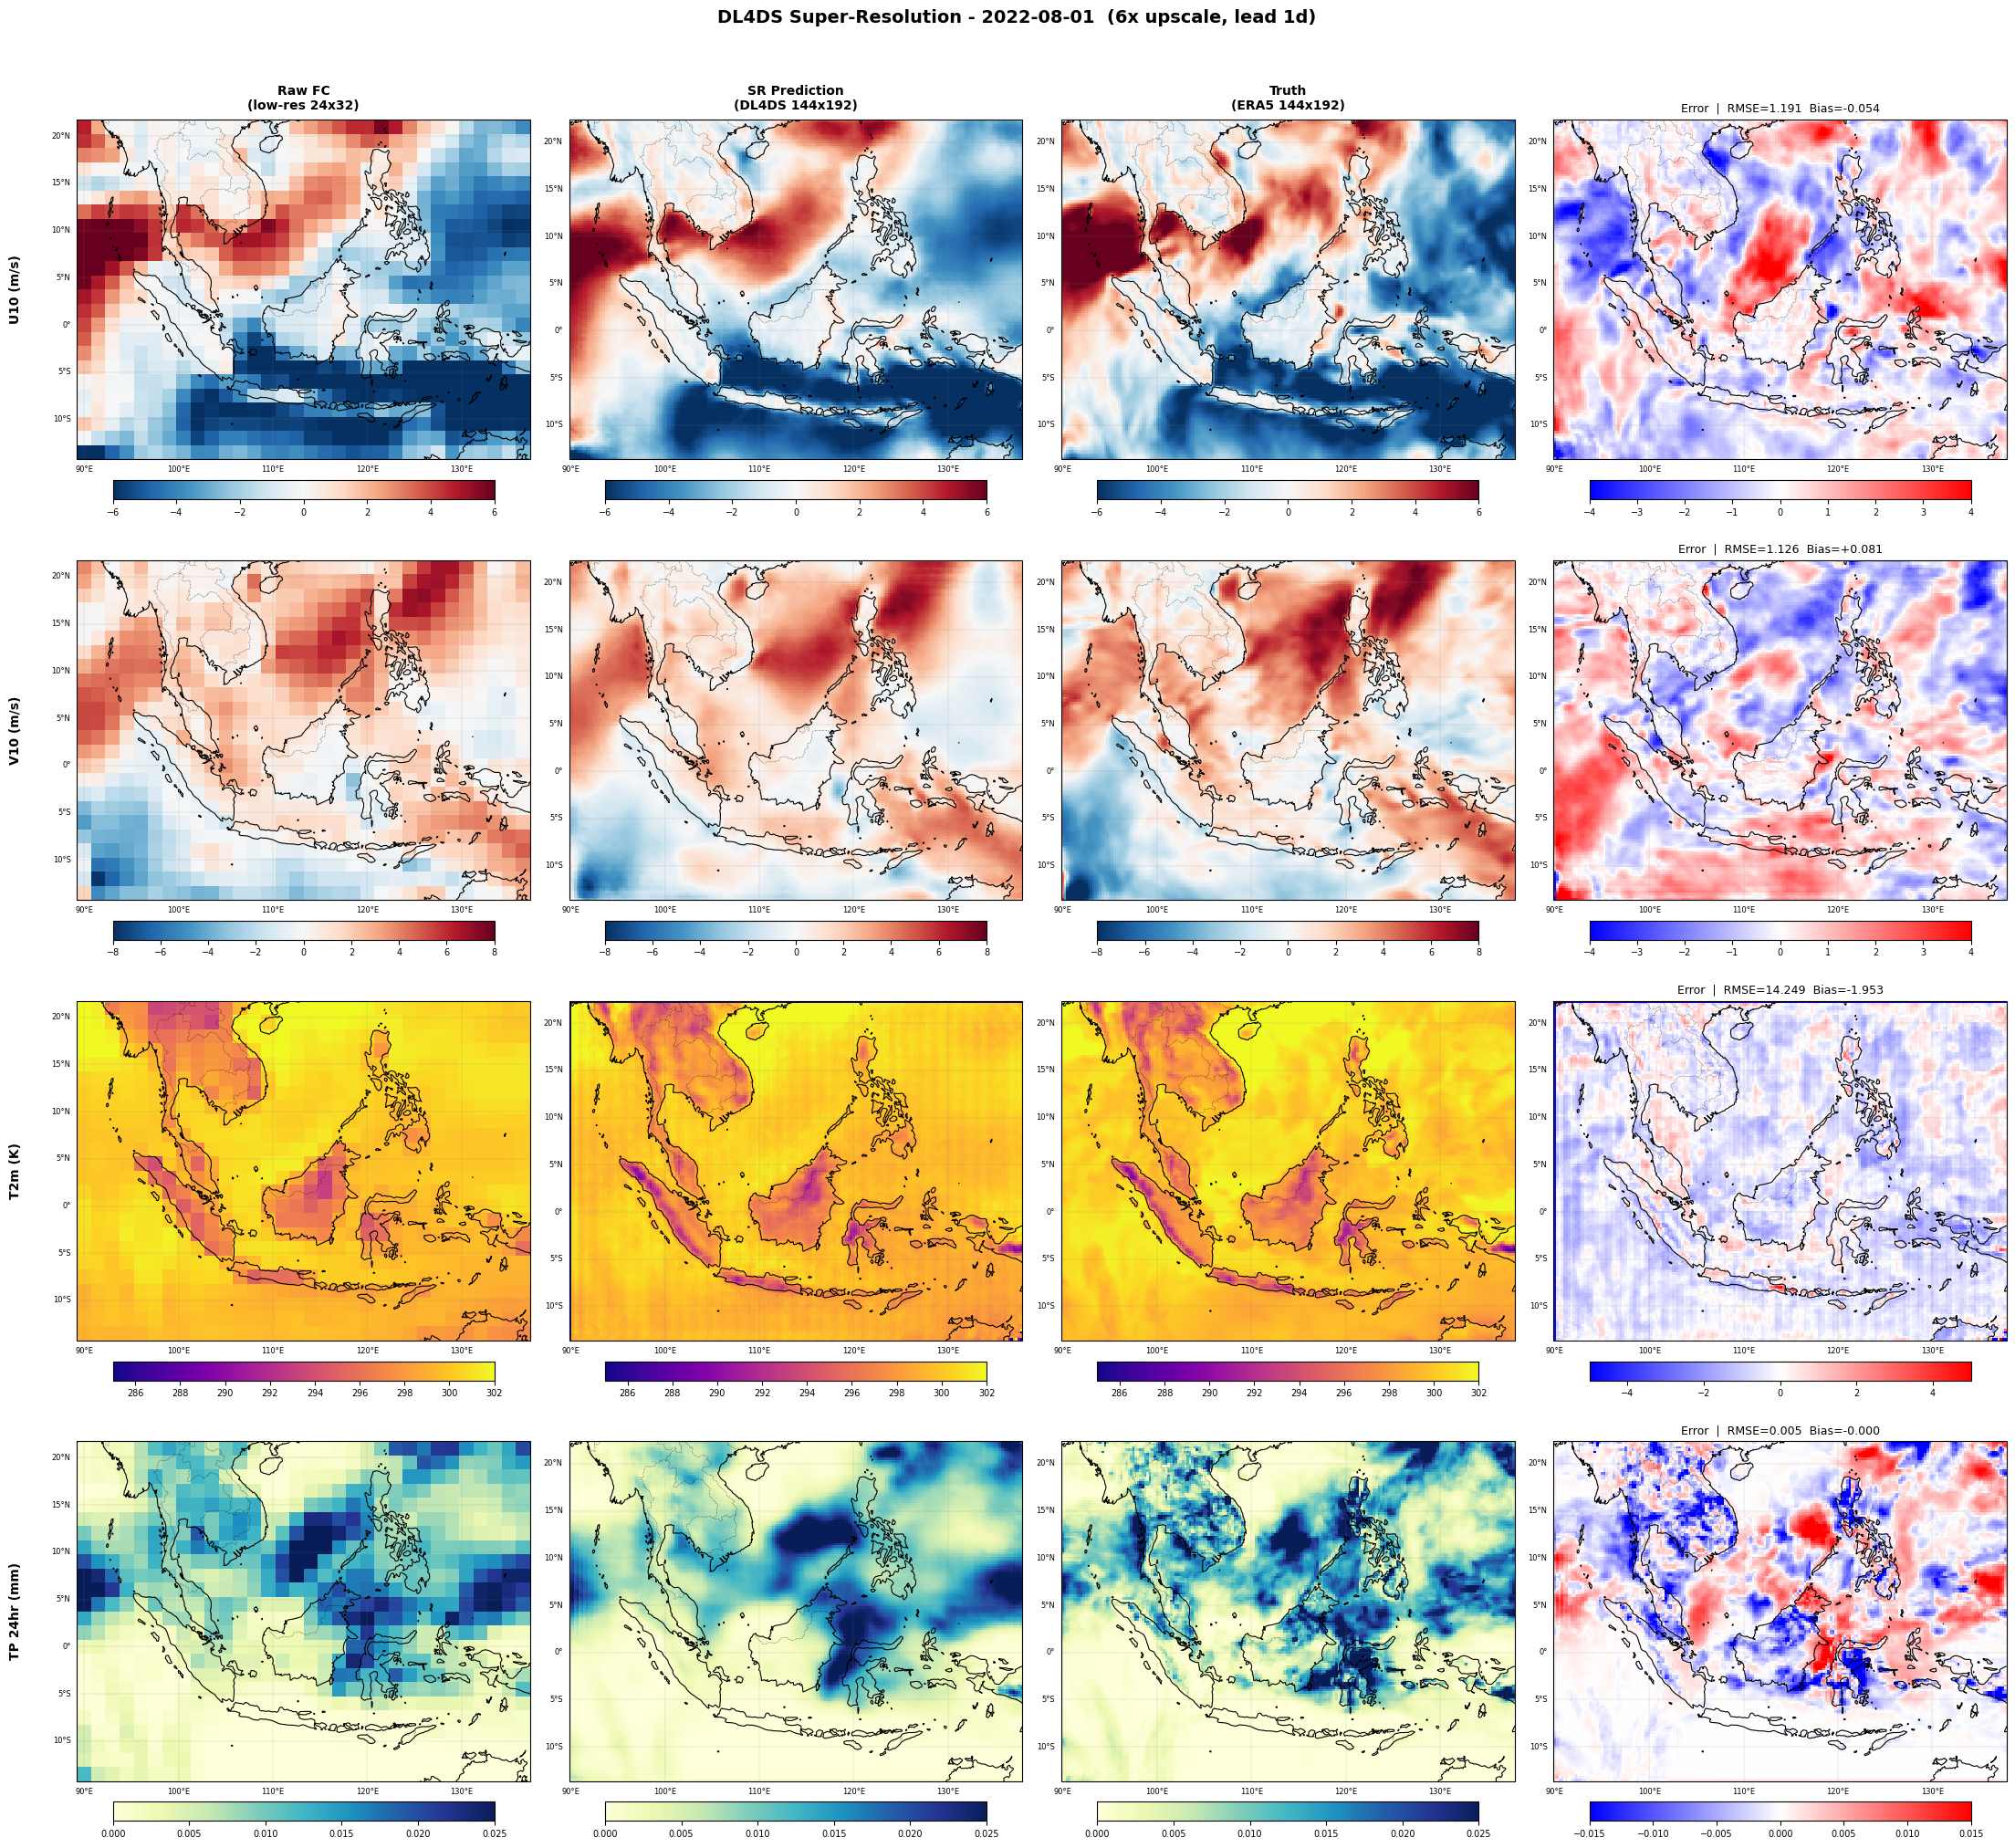


Variable                       |     RMSE |      MAE |     Bias |     Corr |  Baseline RMSE |    Skill
U10 (m/s)                      |   1.1330 |   0.8596 |  -0.0095 |   0.8768 |         1.1679 |  +0.0299
V10 (m/s)                      |   1.1403 |   0.8696 |  +0.1689 |   0.8550 |         1.0916 |  -0.0446
T2m (K)                        |   2.3545 |   2.2242 |  -2.0218 |   0.8205 |         0.7312 |  -2.2199
TP 24hr (mm)                   |   0.0071 |   0.0036 |  -0.0005 |   0.7723 |         0.0060 |  -0.1787
Skill > 0 means DL4DS improves over bilinear interpolation baseline.
[2026-04-14 07:19:28] Metrics saved -> runs/20260414_061341_sc1_dl4ds/metrics.csv
Saved: runs/20260414_061341_sc1_dl4ds/metrics.csv
[2026-04-14 07:19:28] Metrics saved -> runs/20260414_061341_sc1_dl4ds/sc1_dl4ds_metrics.csv
Saved: runs/20260414_061341_sc1_dl4ds/sc1_dl4ds_metrics.csv
[2026-04-14 07:19:28] === Run finished total_elapsed=1:05:46 ===
[2026-04-14 07:19:28] All outputs in: runs/20260414_061341_sc1_dl4

In [13]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

VAR_LABELS_VIZ = [VAR_LABEL_MAP[v] for v in var_names]
target_date = np.datetime64('2022-08-01')

# Hardcoded color ranges (consistent across notebooks for head-to-head)
#                   U10    V10    T2m       TP
FIELD_VMIN = [      -6,    -8,   285,   0.000]
FIELD_VMAX = [       6,     8,   302,   0.025]
ERROR_LIM  = [       4,     4,     5,   0.015]

# Colormaps — same as regrid notebook
cmaps_field = ['RdBu_r', 'RdBu_r', 'plasma', 'YlGnBu']

# ── Save chart config ───────────────────────────────────────────────────
_chart2_cfg = {
    'chart'          : 'spatial_eval',
    'target_date'    : str(target_date),
    'lead_days'      : lead_days,
    'figsize'        : [22, 20],
    'FIELD_VMIN'     : FIELD_VMIN,
    'FIELD_VMAX'     : FIELD_VMAX,
    'ERROR_LIM'      : ERROR_LIM,
    'VAR_LABELS_VIZ' : VAR_LABELS_VIZ,
    'cmaps_field'    : cmaps_field,
}
_json.dump(_chart2_cfg, open(os.path.join(RUN_DIR, 'chart_spatial_eval_config.json'), 'w'), indent=2)
_log('Chart config saved -> chart_spatial_eval_config.json')

# ==============================
# Find index in test split
# ==============================
test_times = eval_cache[var_names[0]]['times']
idx = np.where(test_times == target_date)[0]
if len(idx) == 0:
    raise ValueError(
        f"{target_date} not found in test set.\n"
        f"Available range: {test_times[0]} -> {test_times[-1]}"
    )
idx = idx[0]

# ==============================
# Coordinate arrays
# ==============================
lons_lr = ds_fc.longitude.values
lats_lr = ds_fc.latitude.values
lons_hr = ds_tr_aligned.longitude.values
lats_hr = ds_tr_aligned.latitude.values

# ==============================
# Plot: n_vars rows x 4 cols
# cols: Raw FC | Prediction | Truth | Error
# ==============================
proj   = ccrs.PlateCarree()
n_vars = len(var_names)

col_titles = [
    'Raw FC\n(low-res 24x32)',
    'SR Prediction\n(DL4DS 144x192)',
    'Truth\n(ERA5 144x192)',
    'Error\n(Pred - Truth)',
]

fig, axes = plt.subplots(
    n_vars, 4,
    figsize=(22, 5 * n_vars),
    subplot_kw={'projection': proj},
)
if n_vars == 1:
    axes = np.expand_dims(axes, axis=0)

for v_idx, v_name in enumerate(var_names):
    raw_v  = eval_cache[v_name]['raw'][idx]
    pred_v = eval_cache[v_name]['pred'][idx]
    true_v = eval_cache[v_name]['true'][idx]
    err_v  = pred_v - true_v

    cmap_f = cmaps_field[v_idx] if v_idx < len(cmaps_field) else 'viridis'
    # Hardcoded ranges
    vmin = FIELD_VMIN[v_idx]
    vmax = FIELD_VMAX[v_idx]
    elim = ERROR_LIM[v_idx]

    panels = [
        (lons_lr, lats_lr, raw_v,  cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, pred_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, true_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, err_v,  'bwr',  -elim,  elim),
    ]

    for col, (lons, lats, data_v, cmap, lo, hi) in enumerate(panels):
        ax = axes[v_idx, col]

        if data_v.shape != (len(lats), len(lons)):
            data_v = data_v.T

        im = ax.pcolormesh(
            lons, lats, data_v,
            cmap=cmap, vmin=lo, vmax=hi,
            shading='nearest',
            transform=proj,
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=':')
        ax.add_feature(cfeature.LAND,      facecolor='whitesmoke', zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor='lightcyan',  zorder=0)

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4)
        gl.top_labels   = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 6}
        gl.ylabel_style = {'size': 6}

        cb = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, fraction=0.046)
        cb.ax.tick_params(labelsize=7)

        if v_idx == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight='bold', pad=8)
        if col == 0:
            ax.text(-0.15, 0.5, VAR_LABEL_MAP.get(v_name, v_name), transform=ax.transAxes,
                    fontsize=10, fontweight='bold', va='center', rotation=90)

    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    axes[v_idx, 3].set_title(
        f'Error  |  RMSE={rmse:.3f}  Bias={bias:+.3f}',
        fontsize=9, pad=6,
    )

fig.suptitle(
    f"DL4DS Super-Resolution - {str(target_date)[:10]}  (6x upscale, lead {lead_days}d)",
    fontsize=14, fontweight='bold', y=1.01,
)
plt.tight_layout()
save_fig(fig, f"dl4ds_eval_{str(target_date)[:10]}.png", dpi=150)
plt.show()

# ==============================
# Aggregate test-set evaluation
# (same metric logic as sc1_unet)
# ==============================
rows = []

fc_test_lowres = ds_fc.sel(time=slice(test_start_date, test_end_date)).copy(deep=True)
tr_test_ds = ds_tr_aligned.sel(time=slice(test_start_date, test_end_date))

for v_name in var_names:
    if np.isnan(fc_test_lowres[v_name].values).any():
        fill_val = float(np.nanmean(fc_test_lowres[v_name].values))
        fc_test_lowres[v_name] = fc_test_lowres[v_name].fillna(fill_val)

fc_test_lowres, tr_test_ds = xr.align(fc_test_lowres, tr_test_ds, join='inner')

baseline_rmse_by_var = {}
for v_name in var_names:
    low_da, truth_da_xr = xr.align(fc_test_lowres[v_name], tr_test_ds[v_name], join='inner')
    base_da = low_da.interp(
        latitude=truth_da_xr.latitude,
        longitude=truth_da_xr.longitude,
        method='linear',
    )
    base_da, truth_da_xr = xr.align(base_da, truth_da_xr, join='inner')

    base_v_xr = base_da.transpose('time', 'latitude', 'longitude').values
    true_v_xr = truth_da_xr.transpose('time', 'latitude', 'longitude').values
    rmse_base_grid = np.sqrt(np.mean((base_v_xr - true_v_xr) ** 2, axis=0))
    baseline_rmse_by_var[v_name] = float(np.nanmean(rmse_base_grid))

print('\n' + '=' * 110)
print(f"{'Variable':<30} | {'RMSE':>8} | {'MAE':>8} | {'Bias':>8} | {'Corr':>8} | {'Baseline RMSE':>14} | {'Skill':>8}")
print('=' * 110)

for v_name in var_names:
    pred_v = eval_cache[v_name]['pred']
    true_v = eval_cache[v_name]['true']

    n = min(pred_v.shape[0], true_v.shape[0])
    pred_v = pred_v[:n]
    true_v = true_v[:n]

    rmse_grid = np.sqrt(np.mean((pred_v - true_v) ** 2, axis=0))
    mae_grid = np.mean(np.abs(pred_v - true_v), axis=0)
    bias_grid = np.mean(pred_v - true_v, axis=0)

    pred_diff = pred_v - np.mean(pred_v, axis=0)
    true_diff = true_v - np.mean(true_v, axis=0)
    cov = np.sum(pred_diff * true_diff, axis=0)
    var_pred = np.sum(pred_diff ** 2, axis=0)
    var_true = np.sum(true_diff ** 2, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        corr_grid = cov / np.sqrt(var_pred * var_true)

    rmse = float(np.nanmean(rmse_grid))
    mae = float(np.nanmean(mae_grid))
    bias = float(np.nanmean(bias_grid))
    corr = float(np.nanmean(corr_grid))

    rmse_base = baseline_rmse_by_var[v_name]
    skill = float(1.0 - (rmse / rmse_base)) if rmse_base > 0 else 0.0

    label = VAR_LABEL_MAP.get(v_name, v_name)
    print(f"{label:<30} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

    rows.append({
        'variable': v_name,
        'label': label,
        'RMSE': rmse,
        'MAE': mae,
        'Bias': bias,
        'Corr': corr,
        'Baseline_RMSE': rmse_base,
        'Skill': skill,
    })

print('=' * 110)
print('Skill > 0 means DL4DS improves over bilinear interpolation baseline.')

metrics_df = pd.DataFrame(rows).sort_values('Skill', ascending=False).reset_index(drop=True)
metrics_path = os.path.join(RUN_DIR, 'metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
_log(f'Metrics saved -> {metrics_path}')
print(f'Saved: {metrics_path}')

legacy_metrics_path = os.path.join(RUN_DIR, 'sc1_dl4ds_metrics.csv')
metrics_df.to_csv(legacy_metrics_path, index=False)
_log(f'Metrics saved -> {legacy_metrics_path}')
print(f'Saved: {legacy_metrics_path}')

_total = _dt.datetime.now() - _run_start
_log(f"=== Run finished total_elapsed={str(_total).split('.')[0]} ===")
_log(f'All outputs in: {RUN_DIR}')
